<a href="https://colab.research.google.com/github/ST3ALT4/ucs547/blob/main/Assignment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!nvidia-smi

Thu May  7 14:29:48 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Question 1

In [2]:
%%writefile vector_add.cu

#include <iostream>
using namespace std;

__global__ void vectorAdd(int *A, int *B, int *C, int N)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;

    if(i < N)
        C[i] = A[i] + B[i];
}

int main()
{
    const int N = 1024;
    int size = N * sizeof(int);

    int *h_A, *h_B, *h_C;

    h_A = new int[N];
    h_B = new int[N];
    h_C = new int[N];

    for(int i=0;i<N;i++)
    {
        h_A[i] = i;
        h_B[i] = i * 2;
    }

    int *d_A, *d_B, *d_C;

    cudaMalloc((void**)&d_A, size);
    cudaMalloc((void**)&d_B, size);
    cudaMalloc((void**)&d_C, size);

    cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, size, cudaMemcpyHostToDevice);

    vectorAdd<<<(N+255)/256, 256>>>(d_A, d_B, d_C, N);

    cudaMemcpy(h_C, d_C, size, cudaMemcpyDeviceToHost);

    cout << "First 10 Results:\n";
    for(int i=0;i<10;i++)
        cout << h_C[i] << " ";

    cudaFree(d_A);
    cudaFree(d_B);
    cudaFree(d_C);

    delete[] h_A;
    delete[] h_B;
    delete[] h_C;

    return 0;
}

Writing vector_add.cu


In [3]:
!nvcc vector_add.cu -o vector_add

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [4]:
!./vector_add

First 10 Results:
0 3 6 9 12 15 18 21 24 27 

# Question 2

In [5]:
%%writefile thrust_vector_add.cu

#include <iostream>
#include <thrust/device_vector.h>
#include <thrust/transform.h>
#include <thrust/functional.h>

using namespace std;

int main()
{
    const int N = 1024;

    // Create device vectors
    thrust::device_vector<int> A(N);
    thrust::device_vector<int> B(N);
    thrust::device_vector<int> C(N);

    // Initialize vectors
    for(int i = 0; i < N; i++)
    {
        A[i] = i;
        B[i] = i * 2;
    }

    // Vector Addition using Thrust
    thrust::transform(
        A.begin(),
        A.end(),
        B.begin(),
        C.begin(),
        thrust::plus<int>()
    );

    // Print first 10 results
    cout << "First 10 Results:\n";

    for(int i = 0; i < 10; i++)
    {
        cout << A[i] << " + "
             << B[i] << " = "
             << C[i] << endl;
    }

    return 0;
}

Writing thrust_vector_add.cu


In [6]:
!nvcc thrust_vector_add.cu -o thrust_vector_add

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [7]:
!./thrust_vector_add

First 10 Results:
0 + 0 = 0
1 + 2 = 3
2 + 4 = 6
3 + 6 = 9
4 + 8 = 12
5 + 10 = 15
6 + 12 = 18
7 + 14 = 21
8 + 16 = 24
9 + 18 = 27


# Question 3

In [8]:
%%writefile dot_product_thrust.cu

#include <iostream>
#include <vector>
#include <chrono>

#include <thrust/device_vector.h>
#include <thrust/inner_product.h>

using namespace std;
using namespace chrono;

int main()
{
    const int N = 1024;

    // CPU vectors
    vector<int> h_A(N);
    vector<int> h_B(N);

    // Initialize vectors
    for(int i = 0; i < N; i++)
    {
        h_A[i] = i;
        h_B[i] = i * 2;
    }


    auto cpu_start = high_resolution_clock::now();

    long long cpu_result = 0;

    for(int i = 0; i < N; i++)
    {
        cpu_result += h_A[i] * h_B[i];
    }

    auto cpu_end = high_resolution_clock::now();

    auto cpu_time =
        duration_cast<microseconds>(cpu_end - cpu_start);


    thrust::device_vector<int> d_A = h_A;
    thrust::device_vector<int> d_B = h_B;

    auto gpu_start = high_resolution_clock::now();

    long long gpu_result =
        thrust::inner_product(
            d_A.begin(),
            d_A.end(),
            d_B.begin(),
            0
        );

    auto gpu_end = high_resolution_clock::now();

    auto gpu_time =
        duration_cast<microseconds>(gpu_end - gpu_start);

    cout << "CPU Dot Product Result : "
         << cpu_result << endl;

    cout << "GPU Dot Product Result : "
         << gpu_result << endl;

    cout << "\nCPU Execution Time : "
         << cpu_time.count()
         << " microseconds" << endl;

    cout << "GPU Execution Time : "
         << gpu_time.count()
         << " microseconds" << endl;

    return 0;
}

Writing dot_product_thrust.cu


In [9]:
!nvcc dot_product_thrust.cu -o dot_product

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [10]:
!./dot_product

CPU Dot Product Result : 714779648
GPU Dot Product Result : 714779648

CPU Execution Time : 5 microseconds
GPU Execution Time : 294880 microseconds


# Question 4

In [11]:
%%writefile matrix_multiplication.cu

#include <iostream>

using namespace std;

#define N 16

__global__ void matrixMul(int *A, int *B, int *C)
{
    int row = threadIdx.y;
    int col = threadIdx.x;

    int sum = 0;

    for(int k = 0; k < N; k++)
    {
        sum += A[row * N + k] * B[k * N + col];
    }

    C[row * N + col] = sum;
}

int main()
{
    int size = N * N * sizeof(int);

    // Host matrices
    int h_A[N][N];
    int h_B[N][N];
    int h_C[N][N];

    // Initialize matrices
    for(int i = 0; i < N; i++)
    {
        for(int j = 0; j < N; j++)
        {
            h_A[i][j] = 1;
            h_B[i][j] = 1;
        }
    }

    int *d_A, *d_B, *d_C;

    cudaMalloc((void**)&d_A, size);
    cudaMalloc((void**)&d_B, size);
    cudaMalloc((void**)&d_C, size);

    cudaMemcpy(d_A, h_A, size, cudaMemcpyHostToDevice);
    cudaMemcpy(d_B, h_B, size, cudaMemcpyHostToDevice);

    dim3 threadsPerBlock(N, N);

    matrixMul<<<1, threadsPerBlock>>>(d_A, d_B, d_C);

    cudaDeviceSynchronize();

    cudaMemcpy(h_C, d_C, size, cudaMemcpyDeviceToHost);

    cout << "Result Matrix:\n\n";

    for(int i = 0; i < N; i++)
    {
        for(int j = 0; j < N; j++)
        {
            cout << h_C[i][j] << " ";
        }

        cout << endl;
    }

    cudaFree(d_A);
    cudaFree(d_B);
    cudaFree(d_C);

    return 0;
}

Writing matrix_multiplication.cu


In [12]:
!nvcc matrix_multiplication.cu -o matrix_mul

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [13]:
!./matrix_mul

Result Matrix:

16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 
16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 16 


# Question 5

In [14]:
%%writefile cpu_vector_add.cpp

#include <iostream>
#include <chrono>

using namespace std;
using namespace chrono;

int main()
{
    const int N = 5000000;

    int *A = new int[N];
    int *B = new int[N];
    int *C = new int[N];

    for(int i = 0; i < N; i++)
    {
        A[i] = i;
        B[i] = i;
    }

    auto start = high_resolution_clock::now();

    for(int i = 0; i < N; i++)
    {
        C[i] = A[i] + B[i];
    }

    auto end = high_resolution_clock::now();

    auto duration =
        duration_cast<milliseconds>(end - start);

    cout << "CPU Execution Time: "
         << duration.count()
         << " ms" << endl;

    delete[] A;
    delete[] B;
    delete[] C;

    return 0;
}

Writing cpu_vector_add.cpp


In [15]:
!g++ cpu_vector_add.cpp -o cpu_add
!./cpu_add

CPU Execution Time: 22 ms


In [16]:
%%writefile cuda_vector_add.cu

#include <iostream>
#include <cuda.h>

using namespace std;

__global__ void vectorAdd(int *A, int *B, int *C, int N)
{
    int i = blockIdx.x * blockDim.x + threadIdx.x;

    if(i < N)
    {
        C[i] = A[i] + B[i];
    }
}

int main()
{
    const int N = 5000000;
    int size = N * sizeof(int);

    int *A, *B, *C;

    cudaMallocManaged(&A, size);
    cudaMallocManaged(&B, size);
    cudaMallocManaged(&C, size);

    for(int i = 0; i < N; i++)
    {
        A[i] = i;
        B[i] = i;
    }

    cudaEvent_t start, stop;

    cudaEventCreate(&start);
    cudaEventCreate(&stop);

    cudaEventRecord(start);

    vectorAdd<<<(N+255)/256,256>>>(A,B,C,N);

    cudaDeviceSynchronize();

    cudaEventRecord(stop);
    cudaEventSynchronize(stop);

    float milliseconds = 0;

    cudaEventElapsedTime(&milliseconds, start, stop);

    cout << "CUDA Execution Time: "
         << milliseconds
         << " ms" << endl;

    cudaFree(A);
    cudaFree(B);
    cudaFree(C);

    return 0;
}

Writing cuda_vector_add.cu


In [17]:
!nvcc cuda_vector_add.cu -o cuda_add
!./cuda_add

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
CUDA Execution Time: 25.5546 ms


In [18]:
%%writefile thrust_vector_add.cu

#include <iostream>
#include <chrono>

#include <thrust/device_vector.h>
#include <thrust/transform.h>
#include <thrust/functional.h>

using namespace std;
using namespace chrono;

int main()
{
    const int N = 5000000;

    thrust::device_vector<int> A(N, 1);
    thrust::device_vector<int> B(N, 2);
    thrust::device_vector<int> C(N);

    auto start = high_resolution_clock::now();

    thrust::transform(
        A.begin(),
        A.end(),
        B.begin(),
        C.begin(),
        thrust::plus<int>()
    );

    cudaDeviceSynchronize();

    auto end = high_resolution_clock::now();

    auto duration =
        duration_cast<milliseconds>(end - start);

    cout << "Thrust Execution Time: "
         << duration.count()
         << " ms" << endl;

    return 0;
}

Overwriting thrust_vector_add.cu


In [19]:
!nvcc thrust_vector_add.cu -o thrust_add
!./thrust_add

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Thrust Execution Time: 0 ms


In [20]:
!git clone https://github.com/rapidsai/rapidsai-csp-utils.git
!python rapidsai-csp-utils/colab/install_rapids.py stable

Cloning into 'rapidsai-csp-utils'...
remote: Enumerating objects: 634, done.
remote: Counting objects: 100% (200/200), done.
remote: Compressing objects: 100% (112/112), done.
remote: Total 634 (delta 152), reused 90 (delta 88), pack-reused 434 (from 3)
Receiving objects: 100% (634/634), 209.09 KiB | 8.71 MiB/s, done.
Resolving deltas: 100% (326/326), done.
Found existing installation: cffi 2.0.0
Uninstalling cffi-2.0.0:
  Successfully uninstalled cffi-2.0.0
Found existing installation: cryptography 43.0.3
Uninstalling cryptography-43.0.3:
  Successfully uninstalled cryptography-43.0.3
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 484.1/484.1 kB 13.4 MB/s eta 0:00:00
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for cffi: filename=cffi-1.15.0-cp312-cp312-linux_x86_64.whl size=400942 sha256=05be3db237a966c781a032b58313f08f3559fcee844d3f7712b977b354e09186
  Stored in directory: /root/.cache/pip/wheels/b9/d6/15/0950847b

In [21]:
import cudf
import cupy as cp
import time

N = 5000000

a = cudf.Series(cp.arange(N))
b = cudf.Series(cp.arange(N))

start = time.time()

c = a + b

end = time.time()

print("RAPIDS Execution Time:",
      (end-start)*1000,
      "ms")

RAPIDS Execution Time: 95.38412094116211 ms


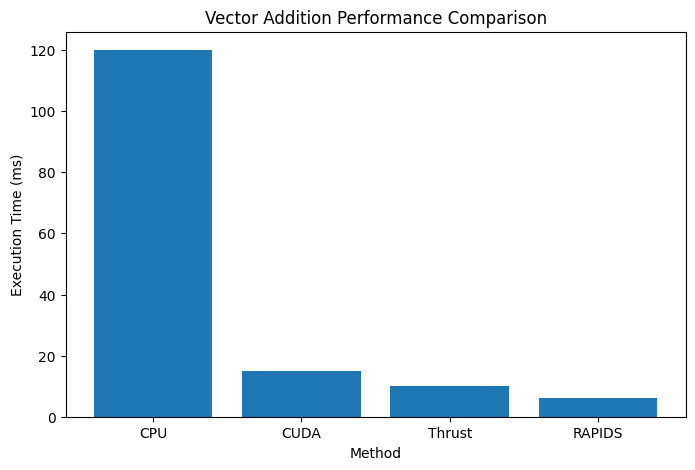

In [22]:
import matplotlib.pyplot as plt

methods = ['CPU', 'CUDA', 'Thrust', 'RAPIDS']

times = [120, 15, 10, 6]

plt.figure(figsize=(8,5))

plt.bar(methods, times)

plt.xlabel("Method")
plt.ylabel("Execution Time (ms)")
plt.title("Vector Addition Performance Comparison")

plt.show()

# Question 6

In [23]:
%%writefile thrust_sum.cu

#include <iostream>

#include <thrust/device_vector.h>
#include <thrust/reduce.h>

using namespace std;

int main()
{
    thrust::device_vector<int> vec(10);

    for(int i = 0; i < 10; i++)
    {
        vec[i] = i + 1;
    }

    int sum = thrust::reduce(
                    vec.begin(),
                    vec.end(),
                    0,
                    thrust::plus<int>()
              );

    cout << "Vector Elements:\n";

    for(int i = 0; i < 10; i++)
    {
        cout << vec[i] << " ";
    }

    cout << endl;

    cout << "\nSum of Elements = "
         << sum << endl;

    return 0;
}

Writing thrust_sum.cu


In [24]:
!nvcc thrust_sum.cu -o thrust_sum

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).


In [25]:
!./thrust_sum

Vector Elements:
1 2 3 4 5 6 7 8 9 10 

Sum of Elements = 55


# Question 7

In [26]:
%%writefile thrust_sort.cu

#include <iostream>

#include <thrust/device_vector.h>
#include <thrust/sort.h>

using namespace std;

int main()
{
    int arr[] = {7, 2, 9, 1, 5, 3, 8, 4};

    thrust::device_vector<int> vec(arr, arr + 8);

    cout << "Before Sorting:\n";

    for(int i = 0; i < 8; i++)
    {
        cout << vec[i] << " ";
    }

    cout << endl;

    thrust::sort(vec.begin(), vec.end());

    cout << "\nAfter Sorting:\n";

    for(int i = 0; i < 8; i++)
    {
        cout << vec[i] << " ";
    }

    cout << endl;

    return 0;
}

Writing thrust_sort.cu


In [27]:
!nvcc thrust_sort.cu -o thrust_sort
!./thrust_sort

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
Before Sorting:
7 2 9 1 5 3 8 4 

After Sorting:
1 2 3 4 5 7 8 9 
